# 结构化生成

使用 LLM 时，我们经常需要用正则表达式来解析 LLM 的输出，比如这样：


In [1]:
import re

answer = """The first 10 digits of pi (π) are as follows:

3.1415926535
"""

regex = r"([0-9]+)?\.[0-9]+"
print(re.search(regex, answer))

<re.Match object; span=(47, 59), match='3.1415926535'>


在这个实操里，我们直接把正则表达式和 LLM 耦合起来，让输出具有精确的正确格式！

我们遵循 Brandon T. Willard 和 Rémi Louf 的 [Efficient Guided Generation for Large Language Models](https://arxiv.org/abs/2307.09702) 的思路。

正则表达式是一种让我们能表达文本模式的语言，库可以用正则处理器找到匹配给定模式的（子）字符串。而如果我们能匹配模式，我们也就能够生成匹配这个模式的文本。

朴素的、由正则引导的生成过程，在每一步都要遍历整个词表来找匹配：
1. 从一个空前缀（空字符串）开始生成。
2. 把词表中的每个 token 拼接到前缀后面。这就给出了所有可能的补全的集合。
3. 对每个可能的补全，用正则的部分匹配特性判断它是否可能导致匹配正则模式的补全。如果不能，就把这个 token 屏蔽，把它的 logit 设为 −∞。
4. 用屏蔽后的 logits 采样一个新 token。
5. 把新 token 拼接到前缀，回到第 (2) 步。

要生成匹配正则 `[0-9]+\.[0-9]` 的字符串，词表为 `["a", ".", ".2", "1"]`，从空字符串 `""` 开始，下面的图演示了我们刚刚描述的过程：
![](https://cdn.prod.website-files.com/665725b00d910f65bec567fc/668c29d45780ee71a367c839_naive.png)


正则处理器的另一个有用特性是执行部分匹配。部分匹配是指一个字符串匹配到它的最后一个字符为止，因此我们可以为它找到本来会匹配该模式的补全。Python 标准的 `re` 库不提供这个功能，但 [regex](https://github.com/mrabarnett/mrab-regex) 库提供了。


In [2]:
import regex as re

regex = r"([0-9]+)?\.[0-9]+"
print(re.fullmatch(regex, '.2', partial=True))

<regex.Match object; span=(0, 2), match='.2'>


In [3]:
print(re.fullmatch(regex, '1.2', partial=True))

<regex.Match object; span=(0, 3), match='1.2'>


In [4]:
print(re.fullmatch(regex, '1.2a', partial=True))

None


In [ ]:
import math
import regex as re
import numpy as np

from scipy.special import softmax

np.random.seed(12349)

logits = np.array([1., 1., 1., 1.])  # logits = np.array([1., 1., 1., 1.])  # 随机模型，概率相等
vocabulary = ["a", ".", ".2", "1"]

regex = r"([0-9]+)?\.[0-9]+"

completion = ""
for _ in range(7):

    # 构建 logit 掩码
    #
    # 你的代码
    #
    masked_logits = logits + mask

    # 采样下一个 token
    probs = softmax(masked_logits)
    next_token_id = np.random.choice(len(vocabulary), p=probs)

    completion += vocabulary[next_token_id]

print(completion)

这对 regex 库支持的任何正则模式都有效，而且不依赖于 LLM 研究者让其他所有人忍受的分词把戏。这不是很美妙吗？

坏消息：这个算法会在你面前爆炸。大型语言模型的典型词表 $V$ 大约包含 5 万个 token，这意味着每生成一个 token，你都需要执行 5 万次部分匹配。在 Python 这样的语言里，部分匹配花费的时间会轻易超过生成下一个 token 的时间。虽然我们在理论上刚刚解决了问题，但这个方案在实践中不可用。

## 确定性有限自动机（DFA），有限状态机（FSM）的一种

1. 从状态 0 和完整字符串开始；
2. 弹出字符串的第一个字符。如果它匹配某条转移规则，就移动到相应的状态。否则我们终止并拒绝该字符串；
3. 一直迭代，直到字符串被拒绝，或者到达 DFA 的某个最终（也叫接受）状态。

给定一个正则表达式，它的 DFA 长什么样？我们考虑之前的正则表达式 `([0-9])?+\.[0-9]+`，用 [interegular](https://github.com/MegaIng/interegular) Python 库把它转换成等价的 DFA 表示：


In [5]:
import interegular

regex = r"([0-9]+)?\.[0-9]+"
fsm = interegular.parse_pattern(regex).to_fsm()

print(fsm)

  name final? . 0 1 2 3 4 5 6 7 8 9 anything_else 
--------------------------------------------------
* 0    False  2 1 1 1 1 1 1 1 1 1 1               
  1    False  2 3 3 3 3 3 3 3 3 3 3               
  2    False    4 4 4 4 4 4 4 4 4 4               
  3    False  2 3 3 3 3 3 3 3 3 3 3               
  4    True     5 5 5 5 5 5 5 5 5 5               
  5    True     5 5 5 5 5 5 5 5 5 5               



In [6]:
print(fsm.alphabet)

anything_else | 0
0-9           | 1
.             | 2


In [7]:
for (start, transitions) in fsm.map.items():
    print(start, transitions)

0 {1: 1, 2: 2}
1 {1: 3, 2: 2}
2 {1: 4}
3 {1: 3, 2: 2}
4 {1: 5}
5 {1: 5}


In [8]:
print(fsm.initial)

0


In [9]:
print(fsm.finals)

frozenset({4, 5})


In [12]:
char_2_str = ['any', ' [0-9]', ' . ']

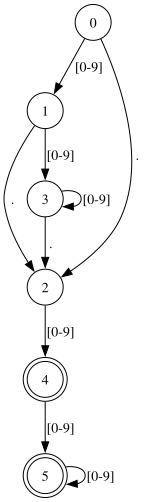

In [13]:
import graphviz
from IPython.display import display

# 定义正则模式
regex = r"([0-9]+)?\.[0-9]+"

# 把正则转换成一个有限状态机（FSM）
fsm = interegular.parse_pattern(regex).to_fsm()

# 生成 Graphviz DOT 格式表示
dot = graphviz.Digraph(format="png")

# 往图里添加状态
for state in fsm.states:
    shape = "doublecircle" if state in fsm.finals else "circle"
    dot.node(str(state), shape=shape)

# 往图里添加转移
for (start, transitions) in fsm.map.items():
    for char, end in transitions.items():
        dot.edge(str(start), str(end), label=char_2_str[char] if char is not None else "ε")

display(dot)

In [ ]:
fsm.map

首先我们需要弄清楚，词表中的 token 是否对应 DFA 状态之间的一条有效路径。这就是下面这个函数要做的事。如果 token 对应一条有效路径（比如 ".2"），我们返回访问过的状态。如果不是（比如 " The"），我们返回 None。


In [ ]:
def partial_match(state, token):
    """Partially match the token to the DFA starting from `state`.

    We iterate over the token's symbols, and at each step transition to the 
    next state if we find a valid transition. 
    If there is a stage without a valid transision, we return None, otherwise
    we return a tuple that contains the sequence of traversed states.

    """
    
    traversed_states = (state,)

    # 遍历 token 的符号，每一步尝试转移
    # 到一个新的 DFA 状态。
    #
    # 你的代码
    #
    
    return traversed_states

In [ ]:
token = ".21"
print(partial_match(0, token))

In [ ]:
token = ".21a"
print(partial_match(0, token))

要构建一个从 DFA 状态到"对应有效补全的 token"的映射，我们需要遍历 DFA 的状态，对每个状态遍历词表，检查 token 是否对应从该状态出发的一条有效路径：


In [ ]:
from collections import defaultdict

vocabulary = ["a", ".", ".2", "1"]

# 从 DFA 状态到对应有效转移的 token 的映射
# （从该状态出发）。
states_to_vocab = defaultdict(set)
#
# 你的代码
#

In [ ]:
states_to_vocab

生成现在可以这样进行：

1. 从状态 0 开始。用 `states_to_vocab[0]` 查找从 0 出发能产生有效补全的 token。
2. 屏蔽 LLM 返回的 logits，使得只能采样这些 token；
3. 用 logits 采样一个新 token。查看 `(state,token)` 对应的路径，路径的最后一个状态就是 DFA 的下一个状态 `new_state`；
4. 用 `states_to_vocab[new_state]` 查找从 `new_state` 出发能产生有效补全的 token。
5. 回到第 (2) 步，直到 FSM 处于某个终止状态、且这个终止状态没有转移。


In [ ]:
np.random.seed(12349) # np.random.seed(12349) # 你应该得到和之前一样的结果

logits = np.array([1., 1., 1., 1.])  # logits = np.array([1., 1., 1., 1.])  # 和之前一样

regex = r"([0-9]+)?\.[0-9]+"

completion = ""
state = fsm.initial
for _ in range(7):

    # 构建 logit 掩码
    #
    # 你的代码
    #

print(completion)

更进一步：[Coalescence: making LLM inference 5x faster](https://blog.dottxt.co/coalescence.html)
